# 02 — Pré-processamento dos Dados do SINAN

## Objetivo

Este notebook corresponde à etapa de pré-processamento dos dados de dengue provenientes do **Sistema de Informação de Agravos de Notificação (SINAN)**.

Seu objetivo é transformar os dados brutos extraídos do arquivo DBF em um conjunto de dados padronizado e adequado para as etapas posteriores de análise epidemiológica e geração de documentos semânticos.

De forma geral, este notebook é responsável por:

1. carregar o arquivo DBF gerado na etapa de extração;
2. verificar a estrutura inicial do conjunto de dados;
3. padronizar os tipos das principais variáveis;
4. tratar códigos geográficos, como UF e município;
5. padronizar ano e semana epidemiológica;
6. decodificar variáveis categóricas relevantes;
7. verificar valores ausentes e inconsistências básicas;
8. salvar o conjunto de dados processado em formato Parquet.

## Organização no pipeline

Dados brutos do SINAN  
↓  
Arquivo DBF  
↓  
Pré-processamento e padronização  
↓  
Dados processados em Parquet  
↓  
Análises epidemiológicas e geração de documentos semânticos

## Observação

Este notebook **não** realiza agregações epidemiológicas específicas, como incidência, hospitalizações, distribuição de sorotipos ou séries temporais. Essas análises são realizadas em notebooks posteriores utilizando o conjunto de dados processado produzido nesta etapa.

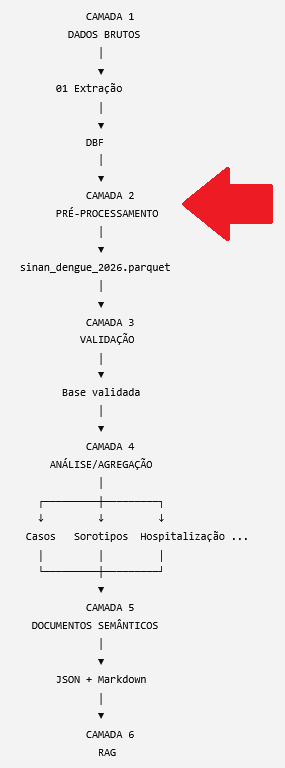

# Importação das bibliotecas

In [1]:
!pip install datasus-dbc dbfread pandas

import os
import pandas as pd
from dbfread import DBF
from google.colab import drive
import datasus_dbc
from datetime import datetime

  Using cached datasus_dbc-0.1.3.tar.gz (6.4 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for datasus-dbc: filename=datasus_dbc-0.1.3-cp313-cp313-linux_x86_64.whl size=254108 sha256=e1d26733466a0890ce074bfe72c6727f5420fa2cf5a2d4f00a9619bbe9a6932e
  Stored in directory: /root/.cache/pip/wheels/c0/88/1b/2db847da0d6159f9db5c6ced423236e209c8cad4fb93bd770b
Successfully built datasus-dbc


Montagem do drive

In [2]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


# 1 - Configuração e criação das pastas

Temos três conceitos bem separados:

| Variável          | Responsabilidade                        |
| ----------------- | --------------------------------------- |
| `PASTA_RAW`       | dados originais/brutos do SINAN         |
| `PASTA_PROCESSED` | dados após limpeza e padronização       |
| `PASTA_DOCS`      | documentos semânticos destinados ao RAG |


In [3]:
from pathlib import Path
import pandas as pd
from dbfread import DBF

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

ANO = 2026
ANO_CURTO = str(ANO)[-2:]

# ============================================================
# DIRETÓRIO BASE DO PROJETO
# ============================================================

PASTA_PROJETO = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

# ============================================================
# DIRETÓRIOS DO SINAN
# ============================================================

PASTA_RAW = (
    PASTA_PROJETO
    / "data_raw"
    / "SINAN"
    / str(ANO)
)

PASTA_PROCESSED = (
    PASTA_PROJETO
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

# ============================================================
# ARQUIVOS
# ============================================================

ARQUIVO_DBF = (
    PASTA_RAW
    / f"DENGBR{ANO_CURTO}.dbf"
)

ARQUIVO_PROCESSADO = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_preprocessado.parquet"
)

# ============================================================
# CRIAÇÃO DO DIRETÓRIO DE SAÍDA
# ============================================================

PASTA_PROCESSED.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Ano de análise: {ANO}")
print(f"Arquivo de entrada: {ARQUIVO_DBF}")
print(f"Arquivo processado: {ARQUIVO_PROCESSADO}")


Ano de análise: 2026
Arquivo de entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbf
Arquivo processado: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_preprocessado.parquet


# 2 - Leitura

In [4]:
# ============================================================
# VERIFICAÇÃO DO ARQUIVO DBF
# ============================================================

if not ARQUIVO_DBF.is_file():
    raise FileNotFoundError(
        f"Arquivo DBF não encontrado: {ARQUIVO_DBF}"
    )

print(f"Lendo arquivo: {ARQUIVO_DBF.name}")

table = DBF(
    str(ARQUIVO_DBF),
    encoding="iso-8859-1",
    load=True
)

df = pd.DataFrame(iter(table))

print("\nDados carregados com sucesso.")
print(f"Registros: {len(df):,}")
print(f"Colunas: {len(df.columns)}")

Lendo arquivo: DENGBR26.dbf

Dados carregados com sucesso.
Registros: 444,266
Colunas: 121


In [5]:
display(df.head())

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,...,0,0,0,0,0,0,2025-11-08,0,0,0
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,...,0,0,0,0,0,0,2026-01-05,0,0,0
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0
4,2,A90,2026-01-05,202601,2026,32,320530,32002,11789,2026-01-05,...,0,0,0,0,0,0,2026-01-05,0,0,0


In [6]:
for i, coluna in enumerate(df.columns, start=1):
    print(f"{i:3} - {coluna}")

  1 - TP_NOT
  2 - ID_AGRAVO
  3 - DT_NOTIFIC
  4 - SEM_NOT
  5 - NU_ANO
  6 - SG_UF_NOT
  7 - ID_MUNICIP
  8 - ID_REGIONA
  9 - ID_UNIDADE
 10 - DT_SIN_PRI
 11 - SEM_PRI
 12 - ANO_NASC
 13 - NU_IDADE_N
 14 - CS_SEXO
 15 - CS_GESTANT
 16 - CS_RACA
 17 - CS_ESCOL_N
 18 - SG_UF
 19 - ID_MN_RESI
 20 - ID_RG_RESI
 21 - ID_PAIS
 22 - DT_INVEST
 23 - ID_OCUPA_N
 24 - FEBRE
 25 - MIALGIA
 26 - CEFALEIA
 27 - EXANTEMA
 28 - VOMITO
 29 - NAUSEA
 30 - DOR_COSTAS
 31 - CONJUNTVIT
 32 - ARTRITE
 33 - ARTRALGIA
 34 - PETEQUIA_N
 35 - LEUCOPENIA
 36 - LACO
 37 - DOR_RETRO
 38 - DIABETES
 39 - HEMATOLOG
 40 - HEPATOPAT
 41 - RENAL
 42 - HIPERTENSA
 43 - ACIDO_PEPT
 44 - AUTO_IMUNE
 45 - DT_CHIK_S1
 46 - DT_CHIK_S2
 47 - DT_PRNT
 48 - RES_CHIKS1
 49 - RES_CHIKS2
 50 - RESUL_PRNT
 51 - DT_SORO
 52 - RESUL_SORO
 53 - DT_NS1
 54 - RESUL_NS1
 55 - DT_VIRAL
 56 - RESUL_VI_N
 57 - DT_PCR
 58 - RESUL_PCR_
 59 - SOROTIPO
 60 - HISTOPA_N
 61 - IMUNOH_N
 62 - HOSPITALIZ
 63 - DT_INTERNA
 64 - UF
 65 - MUNICIPIO

In [7]:
display(df["FEBRE"].head(20))

,FEBRE
0,1
1,1
2,1
3,1
4,1
5,1
6,2
7,1
8,1
9,1


In [8]:
## decodificação dos sinais CLÍNICOS
# ============================================================
# INSPEÇÃO DA ESTRUTURA DOS DADOS
# ============================================================

print("Dimensões:")
print(df.shape)

print("\nColunas disponíveis:")
for coluna in df.columns:
    print(coluna)

Dimensões:
(444266, 121)

Colunas disponíveis:
TP_NOT
ID_AGRAVO
DT_NOTIFIC
SEM_NOT
NU_ANO
SG_UF_NOT
ID_MUNICIP
ID_REGIONA
ID_UNIDADE
DT_SIN_PRI
SEM_PRI
ANO_NASC
NU_IDADE_N
CS_SEXO
CS_GESTANT
CS_RACA
CS_ESCOL_N
SG_UF
ID_MN_RESI
ID_RG_RESI
ID_PAIS
DT_INVEST
ID_OCUPA_N
FEBRE
MIALGIA
CEFALEIA
EXANTEMA
VOMITO
NAUSEA
DOR_COSTAS
CONJUNTVIT
ARTRITE
ARTRALGIA
PETEQUIA_N
LEUCOPENIA
LACO
DOR_RETRO
DIABETES
HEMATOLOG
HEPATOPAT
RENAL
HIPERTENSA
ACIDO_PEPT
AUTO_IMUNE
DT_CHIK_S1
DT_CHIK_S2
DT_PRNT
RES_CHIKS1
RES_CHIKS2
RESUL_PRNT
DT_SORO
RESUL_SORO
DT_NS1
RESUL_NS1
DT_VIRAL
RESUL_VI_N
DT_PCR
RESUL_PCR_
SOROTIPO
HISTOPA_N
IMUNOH_N
HOSPITALIZ
DT_INTERNA
UF
MUNICIPIO
TPAUTOCTO
COUFINF
COPAISINF
COMUNINF
CLASSI_FIN
CRITERIO
DOENCA_TRA
CLINC_CHIK
EVOLUCAO
DT_OBITO
DT_ENCERRA
ALRM_HIPOT
ALRM_PLAQ
ALRM_VOM
ALRM_SANG
ALRM_HEMAT
ALRM_ABDOM
ALRM_LETAR
ALRM_HEPAT
ALRM_LIQ
DT_ALRM
GRAV_PULSO
GRAV_CONV
GRAV_ENCH
GRAV_INSUF
GRAV_TAQUI
GRAV_EXTRE
GRAV_HIPOT
GRAV_HEMAT
GRAV_MELEN
GRAV_METRO
GRAV_SANG
GRAV_AST
GRAV_M

In [9]:
# ============================================================
# TIPOS DE DADOS ORIGINAIS
# ============================================================

tipos_originais = (
    df.dtypes
    .astype(str)
    .to_frame(
        name="TIPO_ORIGINAL"
    )
)

display(
    tipos_originais
)

,TIPO_ORIGINAL
TP_NOT,object
ID_AGRAVO,object
DT_NOTIFIC,object
SEM_NOT,object
NU_ANO,object
...,...
NDUPLIC_N,object
DT_DIGITA,object
CS_FLXRET,object
FLXRECEBI,object


# 3 - Padronizar os campos mais importantes ou Padronização das variáveis estruturais

In [10]:
COLUNAS_ESTRUTURAIS = [
    "NU_ANO",
    "SEM_NOT",
    "SG_UF_NOT",
    "ID_MUNICIP"
]
for coluna in COLUNAS_ESTRUTURAIS:

    if coluna in df.columns:
        print(f"{coluna}: encontrada")

    else:
        print(f"{coluna}: NÃO encontrada")

NU_ANO: encontrada
SEM_NOT: encontrada
SG_UF_NOT: encontrada
ID_MUNICIP: encontrada


E aplicar:

In [11]:
# ============================================================
# PADRONIZAÇÃO DAS VARIÁVEIS ESTRUTURAIS
# ============================================================

for coluna in COLUNAS_ESTRUTURAIS:

    if coluna in df.columns:

        df[coluna] = (
            pd.to_numeric(
                df[coluna],
                errors="coerce"
            )
            .astype("Int64")
        )

        print(
            f"{coluna}: padronizada"
        )

NU_ANO: padronizada
SEM_NOT: padronizada
SG_UF_NOT: padronizada
ID_MUNICIP: padronizada


In [12]:
# ============================================================
# EXTRAÇÃO DA SEMANA EPIDEMIOLÓGICA
# ============================================================

df["SEMANA_EPIDEMIOLOGICA"] = (
    df["SEM_NOT"] % 100
).astype("Int64")

In [13]:
# ============================================================
# EXTRAÇÃO DO ANO A PARTIR DE SEM_NOT
# ============================================================

df["ANO_SEM_NOT"] = (
    df["SEM_NOT"] // 100
).astype("Int64")

Verificando se NU_ANO e SEM_NOT são coerentes
Se não for zero, não devemos corrigir automaticamente; primeiro investigamos.

In [14]:
# ============================================================
# CONSISTÊNCIA ENTRE NU_ANO E SEM_NOT
# ============================================================

inconsistencias_ano = df[
    df["NU_ANO"].notna()
    & df["ANO_SEM_NOT"].notna()
    & (df["NU_ANO"] != df["ANO_SEM_NOT"])
]

print(
    f"Registros com inconsistência entre NU_ANO e SEM_NOT: "
    f"{len(inconsistencias_ano):,}"
)

Registros com inconsistência entre NU_ANO e SEM_NOT: 0


Agora a verificação das semanas fica melhor

In [15]:
# ============================================================
# VERIFICAÇÃO DAS SEMANAS EPIDEMIOLÓGICAS
# ============================================================

print(
    "Semana epidemiológica mínima:",
    df["SEMANA_EPIDEMIOLOGICA"].min()
)

print(
    "Semana epidemiológica máxima:",
    df["SEMANA_EPIDEMIOLOGICA"].max()
)

print(
    "Semanas epidemiológicas encontradas:"
)

print(
    sorted(
        df["SEMANA_EPIDEMIOLOGICA"]
        .dropna()
        .unique()
    )
)

Semana epidemiológica mínima: 1
Semana epidemiológica máxima: 34
Semanas epidemiológicas encontradas:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]


# 4 - Padronização das Unidades Federativas

In [16]:
# ============================================================
# MAPEAMENTO DAS UNIDADES FEDERATIVAS
# ============================================================

MAPA_UF = {
    11: "Rondônia",
    12: "Acre",
    13: "Amazonas",
    14: "Roraima",
    15: "Pará",
    16: "Amapá",
    17: "Tocantins",
    21: "Maranhão",
    22: "Piauí",
    23: "Ceará",
    24: "Rio Grande do Norte",
    25: "Paraíba",
    26: "Pernambuco",
    27: "Alagoas",
    28: "Sergipe",
    29: "Bahia",
    31: "Minas Gerais",
    32: "Espírito Santo",
    33: "Rio de Janeiro",
    35: "São Paulo",
    41: "Paraná",
    42: "Santa Catarina",
    43: "Rio Grande do Sul",
    50: "Mato Grosso do Sul",
    51: "Mato Grosso",
    52: "Goiás",
    53: "Distrito Federal"
}

df["UF_NAME"] = (
    df["SG_UF_NOT"]
    .map(MAPA_UF)
)

Depois validamos

In [17]:
# ============================================================
# VERIFICAÇÃO DAS UNIDADES FEDERATIVAS
# ============================================================

ufs_encontradas = (
    df[
        [
            "SG_UF_NOT",
            "UF_NAME"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "SG_UF_NOT"
    )
)

display(
    ufs_encontradas
)

print(
    f"Quantidade de UFs: "
    f"{df['SG_UF_NOT'].nunique()}"
)

,SG_UF_NOT,UF_NAME
20026,11,Rondônia
19276,12,Acre
26514,13,Amazonas
352502,14,Roraima
27131,15,Pará
27951,16,Amapá
27689,17,Tocantins
30222,21,Maranhão
19992,22,Piauí
26660,23,Ceará


Quantidade de UFs: 27


# 5 - Verificação da última semana de notificação do SINAN

In [18]:
df['SEM_NOT'].max()

np.int64(202634)

# 6 - Inspeção das variáveis categóricas

Agora entramos em SOROTIPO, HOSPITALIZ e EVOLUCAO.

Antes de decodificá-las, quero separar inspeção de transformação.

Variáveis selecionadas. Essa célula é importante porque permite verificar os códigos antes de aplicarmos qualquer interpretação.

In [19]:
# ============================================================
# VARIÁVEIS CATEGÓRICAS SELECIONADAS
# ============================================================

COLUNAS_SINAIS_CLINICOS = [
    "FEBRE",
    "MIALGIA",
    "CEFALEIA",
    "EXANTEMA",
    "VOMITO",
    "NAUSEA",
    "DOR_COSTAS",
    "CONJUNTVIT",
    "ARTRITE",
    "ARTRALGIA",
    "PETEQUIA_N",
    "LEUCOPENIA",
    "LACO",
    "DOR_RETRO"
]

COLUNAS_DOENCAS_PREEXISTENTES = [
    "DIABETES",
    "HEMATOLOG",
    "HEPATOPAT",
    "RENAL",
    "HIPERTENSA",
    "ACIDO_PEPT",
    "AUTO_IMUNE"
]

COLUNAS_CATEGORICAS = [
    "SOROTIPO",
    "HOSPITALIZ",
    "EVOLUCAO",
    "TPAUTOCTO"
] + COLUNAS_SINAIS_CLINICOS + COLUNAS_DOENCAS_PREEXISTENTES

for coluna in COLUNAS_CATEGORICAS:

    if coluna in df.columns:

        print("\n" + "=" * 60)
        print(coluna)
        print("=" * 60)

        display(
            df[coluna]
            .value_counts(
                dropna=False
            )
            .sort_index()
        )

    else:

        print(
            f"{coluna}: NÃO encontrada"
        )


SOROTIPO


,count
SOROTIPO,
,397575
0,17174
1,1631
2,18763
3,9017
4,106



HOSPITALIZ


,count
HOSPITALIZ,
,109079
0,1
1,27589
2,298342
9,9255



EVOLUCAO


...

,count
HIPERTENSA,
,15593
1,33179
2,395488
9,6



ACIDO_PEPT


,count
ACIDO_PEPT,
,15593
1,2139
2,426529
9,5



AUTO_IMUNE


,count
AUTO_IMUNE,
,15593
1,2761
2,425907
9,5


# 7 - Padronização das variáveis categóricas

In [20]:
# ============================================================
# PADRONIZAÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

for coluna in COLUNAS_CATEGORICAS:

    if coluna in df.columns:

        df[coluna] = (
            pd.to_numeric(
                df[coluna],
                errors="coerce"
            )
            .astype("Int64")
        )

        print(
            f"{coluna}: padronizada"
        )

SOROTIPO: padronizada
HOSPITALIZ: padronizada
EVOLUCAO: padronizada
TPAUTOCTO: padronizada
FEBRE: padronizada
MIALGIA: padronizada
CEFALEIA: padronizada
EXANTEMA: padronizada
VOMITO: padronizada
NAUSEA: padronizada
DOR_COSTAS: padronizada
CONJUNTVIT: padronizada
ARTRITE: padronizada
ARTRALGIA: padronizada
PETEQUIA_N: padronizada
LEUCOPENIA: padronizada
LACO: padronizada
DOR_RETRO: padronizada
DIABETES: padronizada
HEMATOLOG: padronizada
HEPATOPAT: padronizada
RENAL: padronizada
HIPERTENSA: padronizada
ACIDO_PEPT: padronizada
AUTO_IMUNE: padronizada


In [21]:
# ============================================================
# CRIAÇÃO DAS VARIÁVEIS ANALÍTICAS
# ============================================================

df["SOROTIPO_ANALITICO"] = (
    df["SOROTIPO"]
    .replace(0, pd.NA)
)

df["HOSPITALIZ_ANALITICO"] = (
    df["HOSPITALIZ"]
    .replace(0, pd.NA)
)

df["EVOLUCAO_ANALITICO"] = (
    df["EVOLUCAO"]
    .replace(0, pd.NA)
)

Assim, os códigos originais continuam preservados em:

SOROTIPO
HOSPITALIZ
EVOLUCAO

e as versões usadas para análise ficam em:

SOROTIPO_ANALITICO
HOSPITALIZ_ANALITICO
EVOLUCAO_ANALITICO

# 8 - Decodificação do sorotipo

In [22]:
# ============================================================
# DECODIFICAÇÃO DO SOROTIPO
# ============================================================

MAPA_SOROTIPO = {
    1: "DENV-1",
    2: "DENV-2",
    3: "DENV-3",
    4: "DENV-4"
}

df["SOROTIPO_DECODED"] = (
    df["SOROTIPO_ANALITICO"]
    .map(MAPA_SOROTIPO)
)

# 9. Decodificação da hospitalização

In [23]:
# ============================================================
# DECODIFICAÇÃO DA HOSPITALIZAÇÃO
# ============================================================

MAPA_HOSPITALIZ = {
    1: "Sim",
    2: "Não",
    9: "Ignorado"
}

df["HOSPITALIZ_DECODED"] = (
    df["HOSPITALIZ_ANALITICO"]
    .map(MAPA_HOSPITALIZ)
)

# 10. Decodificação da evolução

Aqui há uma cautela: confirme os códigos de EVOLUCAO no dicionário de dados correspondente ao seu arquivo do SINAN antes de consolidar este mapa.

Se os códigos do seu layout forem os que estamos considerando:

In [24]:
# ============================================================
# DECODIFICAÇÃO DA EVOLUÇÃO
# ============================================================

MAPA_EVOLUCAO = {
    1: "Cura",
    2: "Óbito pelo agravo",
    3: "Óbito por outras causas",
    4: "Óbito em investigação",
    9: "Ignorado"
}

df["EVOLUCAO_DECODED"] = (
    df["EVOLUCAO_ANALITICO"]
    .map(MAPA_EVOLUCAO)
)

#  Decodificação dos sinais clínicos

In [25]:
# ============================================================
# DECODIFICAÇÃO DOS SINAIS CLÍNICOS
# E DOENÇAS PRÉ-EXISTENTES
# ============================================================

MAPA_SIM_NAO = {
    1: "Sim",
    2: "Não"
}

COLUNAS_SIM_NAO = (
    COLUNAS_SINAIS_CLINICOS
    + COLUNAS_DOENCAS_PREEXISTENTES
)

for coluna in COLUNAS_SIM_NAO:

    if coluna in df.columns:

        df[f"{coluna}_DECODED"] = (
            df[coluna]
            .map(MAPA_SIM_NAO)
        )

#  Decodificação da autoctonia

In [26]:
# ============================================================
# DECODIFICAÇÃO DA AUTOCTONIA
# ============================================================

MAPA_TPAUTOCTO = {
    1: "Sim",
    2: "Não",
    3: "Indeterminado"
}

df["TPAUTOCTO_DECODED"] = (
    df["TPAUTOCTO"]
    .map(MAPA_TPAUTOCTO)
)

# 11. Verificação das decodificações

Em vez de escrever três códigos praticamente iguais, podemos criar uma função.

In [27]:
# ============================================================
# FUNÇÃO PARA VERIFICAR DECODIFICAÇÕES
# ============================================================

def verificar_decodificacao(
    dataframe,
    coluna_original,
    coluna_decodificada
):

    resultado = (
        dataframe[
            [
                coluna_original,
                coluna_decodificada
            ]
        ]
        .value_counts(
            dropna=False
        )
        .reset_index(
            name="TOTAL"
        )
        .sort_values(
            coluna_original,
            na_position="last"
        )
    )

    display(
        resultado
    )

In [28]:
# ============================================================
# VERIFICAÇÃO DAS DECODIFICAÇÕES
# ============================================================

for coluna in COLUNAS_SIM_NAO:

    if (
        coluna in df.columns
        and f"{coluna}_DECODED" in df.columns
    ):

        print("\n" + "=" * 60)
        print(f"DECODIFICAÇÃO: {coluna}")
        print("=" * 60)

        verificar_decodificacao(
            df,
            coluna,
            f"{coluna}_DECODED"
        )


DECODIFICAÇÃO: FEBRE


,FEBRE,FEBRE_DECODED,TOTAL
0,1,Sim,378134
1,2,Não,50539
2,<NA>,NaN,15593



DECODIFICAÇÃO: MIALGIA


,MIALGIA,MIALGIA_DECODED,TOTAL
0,1,Sim,339154
1,2,Não,89519
2,<NA>,NaN,15593



DECODIFICAÇÃO: CEFALEIA


...

,HIPERTENSA,HIPERTENSA_DECODED,TOTAL
1,1,Sim,33179
0,2,Não,395488
3,9,NaN,6
2,<NA>,NaN,15593



DECODIFICAÇÃO: ACIDO_PEPT


,ACIDO_PEPT,ACIDO_PEPT_DECODED,TOTAL
2,1,Sim,2139
0,2,Não,426529
3,9,NaN,5
1,<NA>,NaN,15593



DECODIFICAÇÃO: AUTO_IMUNE


,AUTO_IMUNE,AUTO_IMUNE_DECODED,TOTAL
2,1,Sim,2761
0,2,Não,425907
3,9,NaN,5
1,<NA>,NaN,15593


Sorotipo

In [29]:
verificar_decodificacao(
    df,
    "SOROTIPO",
    "SOROTIPO_DECODED"
)

,SOROTIPO,SOROTIPO_DECODED,TOTAL
2,0,NaN,17174
4,1,DENV-1,1631
1,2,DENV-2,18763
3,3,DENV-3,9017
5,4,DENV-4,106
0,<NA>,NaN,397575


Hospitalização

In [30]:
verificar_decodificacao(
    df,
    "HOSPITALIZ",
    "HOSPITALIZ_DECODED"
)

,HOSPITALIZ,HOSPITALIZ_DECODED,TOTAL
4,0,NaN,1
2,1,Sim,27589
0,2,Não,298342
3,9,Ignorado,9255
1,<NA>,NaN,109079


Evolução

In [31]:
verificar_decodificacao(
    df,
    "EVOLUCAO",
    "EVOLUCAO_DECODED"
)

,EVOLUCAO,EVOLUCAO_DECODED,TOTAL
3,0,NaN,5048
0,1,Cura,309059
4,2,Óbito pelo agravo,303
6,3,Óbito por outras causas,102
5,4,Óbito em investigação,154
2,9,Ignorado,13838
1,<NA>,NaN,115762


Autóctone

In [32]:
verificar_decodificacao(
    df,
    "TPAUTOCTO",
    "TPAUTOCTO_DECODED"
)

,TPAUTOCTO,TPAUTOCTO_DECODED,TOTAL
4,0,NaN,12
0,1,Sim,257191
3,2,Não,6023
2,3,Indeterminado,18002
1,<NA>,NaN,163038


# 12 - Verificações estruturais

Agora fazemos algumas verificações antes de salvar.

Ano

In [33]:
# ============================================================
# VERIFICAÇÃO DO ANO
# ============================================================

print(
    "Anos encontrados:"
)

print(
    sorted(
        df["NU_ANO"]
        .dropna()
        .unique()
    )
)

Anos encontrados:
[np.int64(2026)]


Semanas epidemiológicas

In [34]:
# ============================================================
# VERIFICAÇÃO DAS SEMANAS EPIDEMIOLÓGICAS
# ============================================================

print(
    "Semana mínima:",
    df["SEM_NOT"].min()
)

print(
    "Semana máxima:",
    df["SEM_NOT"].max()
)

print(
    "Semanas encontradas:"
)

print(
    sorted(
        df["SEM_NOT"]
        .dropna()
        .unique()
    )
)

Semana mínima: 202601
Semana máxima: 202634
Semanas encontradas:
[np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606), np.int64(202607), np.int64(202608), np.int64(202609), np.int64(202610), np.int64(202611), np.int64(202612), np.int64(202613), np.int64(202614), np.int64(202615), np.int64(202616), np.int64(202617), np.int64(202618), np.int64(202619), np.int64(202620), np.int64(202621), np.int64(202622), np.int64(202623), np.int64(202624), np.int64(202625), np.int64(202626), np.int64(202627), np.int64(202628), np.int64(202629), np.int64(202630), np.int64(202631), np.int64(202632), np.int64(202633), np.int64(202634)]


UFs sem correspondência

In [35]:
# ============================================================
# VERIFICAÇÃO DE UFs SEM MAPEAMENTO
# ============================================================

ufs_sem_mapeamento = (
    df.loc[
        df["SG_UF_NOT"].notna()
        & df["UF_NAME"].isna(),
        "SG_UF_NOT"
    ]
    .value_counts()
)

if ufs_sem_mapeamento.empty:

    print(
        "Todos os códigos de UF foram mapeados."
    )

else:

    print(
        "ATENÇÃO: códigos de UF sem mapeamento:"
    )

    display(
        ufs_sem_mapeamento
    )

Todos os códigos de UF foram mapeados.


# Resumo do pré-processamento

In [36]:
# ============================================================
# RESUMO DO PRÉ-PROCESSAMENTO
# ============================================================

print("\n" + "=" * 60)
print("RESUMO DO PRÉ-PROCESSAMENTO")
print("=" * 60)

print(f"Ano: {ANO}")
print(f"Registros: {len(df):,}")
print(f"Colunas: {len(df.columns)}")

print(
    f"UFs identificadas: "
    f"{df['SG_UF_NOT'].nunique()}"
)

print(
    f"Semana epidemiológica mínima: "
    f"{df['SEMANA_EPIDEMIOLOGICA'].min()}"
)

print(
    f"Semana epidemiológica máxima: "
    f"{df['SEMANA_EPIDEMIOLOGICA'].max()}"
)

print("=" * 60)


RESUMO DO PRÉ-PROCESSAMENTO
Ano: 2026
Registros: 444,266
Colunas: 152
UFs identificadas: 27
Semana epidemiológica mínima: 1
Semana epidemiológica máxima: 34


# 14. Salvamento dos dados processados

In [37]:
# ============================================================
# SALVAMENTO EM PARQUET
# ============================================================

df.to_parquet(
    ARQUIVO_PROCESSADO,
    index=False
)

print(
    "Dados processados salvos com sucesso."
)

print(
    f"Arquivo: {ARQUIVO_PROCESSADO}"
)

Dados processados salvos com sucesso.
Arquivo: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_preprocessado.parquet


Verificação final

In [38]:
# ============================================================
# VERIFICAÇÃO DO ARQUIVO GERADO
# ============================================================

if not ARQUIVO_PROCESSADO.is_file():

    raise RuntimeError(
        "O arquivo Parquet não foi gerado."
    )

tamanho_mb = (
    ARQUIVO_PROCESSADO.stat().st_size
    / (1024 ** 2)
)

print(
    f"Arquivo validado: "
    f"{ARQUIVO_PROCESSADO.name}"
)

print(
    f"Tamanho: {tamanho_mb:.2f} MB"
)

Arquivo validado: sinan_dengue_2026_preprocessado.parquet
Tamanho: 12.99 MB


O que teremos ao final ? o Arquivo G:\Meu Drive\Doutorado\arbovirus_rag\data_processed\SINAN\2026\sinan_dengue_2026_preprocessado.parquet

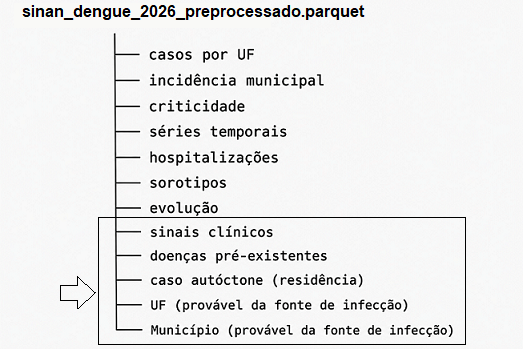